In [8]:
import pandas as pd
import numpy as np
df=pd.read_csv("C:\\Users\\ADMIN\\Desktop\\ESM PROJECT\\esm_E-commerce_Project\\data\\cleaned_data.csv")

In [10]:
df.head(20)

,Customer_ID,Customer_Name,Quantity,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,2023-04-14
1,2,Sophia Hall,59,India,Beauty,738.56,PayPal,2023-07-30
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,2023-09-17
3,4,Elijah White,43,Mexico,Sports,401.09,UPI,2023-06-21
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,2024-10-29
5,6,Elijah Harris,51,India,Toys,966.50,Cash on Delivery,2025-01-18
6,7,Oliver Clark,27,Germany,Home & Kitchen,341.73,Credit Card,2024-03-13
7,8,OLIVIA ALLEN,46,Canada,Home & Kitchen,11.33,Debit Card,2024-01-04
8,9,Liam Harris,54,France,Beauty,279.43,Cash on Delivery,2023-12-06
9,10,Liam Allen,60,Canada,Toys,223.90,Cash on Delivery,2023-08-07


In [18]:
df.shape

(48572, 8)

In [19]:
df.describe()

,Customer_ID,Quantity,Purchase_Amount
count,48572.000000,48572.000000,48572.000000
mean,24990.090896,41.899263,503.228936
std,14429.612771,17.583555,282.344968
min,1.000000,0.000000,5.040000
25%,12497.750000,29.000000,262.665000
50%,24977.500000,43.000000,503.180000
75%,37485.250000,57.000000,743.922500
max,50000.000000,70.000000,999.980000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48572 entries, 0 to 48571
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       48572 non-null  int64  
 1   Customer_Name     48572 non-null  object 
 2   Quantity          48572 non-null  int64  
 3   Country           48572 non-null  object 
 4   Product_Category  48572 non-null  object 
 5   Purchase_Amount   48572 non-null  float64
 6   Payment_Method    48572 non-null  object 
 7   Transaction_Date  48572 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 3.0+ MB


In [14]:
df.isnull().values.any()

np.False_

In [17]:
df.isnull().sum()

Customer_ID         0
Customer_Name       0
Quantity            0
Country             0
Product_Category    0
Purchase_Amount     0
Payment_Method      0
Transaction_Date    0
dtype: int64

In [20]:
df.head(20)

,Customer_ID,Customer_Name,Quantity,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,2023-04-14
1,2,Sophia Hall,59,India,Beauty,738.56,PayPal,2023-07-30
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,2023-09-17
3,4,Elijah White,43,Mexico,Sports,401.09,UPI,2023-06-21
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,2024-10-29
5,6,Elijah Harris,51,India,Toys,966.50,Cash on Delivery,2025-01-18
6,7,Oliver Clark,27,Germany,Home & Kitchen,341.73,Credit Card,2024-03-13
7,8,OLIVIA ALLEN,46,Canada,Home & Kitchen,11.33,Debit Card,2024-01-04
8,9,Liam Harris,54,France,Beauty,279.43,Cash on Delivery,2023-12-06
9,10,Liam Allen,60,Canada,Toys,223.90,Cash on Delivery,2023-08-07


In [ ]:
#Ensures consistent and clean text data, which improves data analysis accuracy#

text_cols = ['Customer_Name', 'Country', 'Product_Category', 'Payment_Method']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [ ]:
#The function identifies abnormal values by comparing data against a statistically defined normal range using IQR#

def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

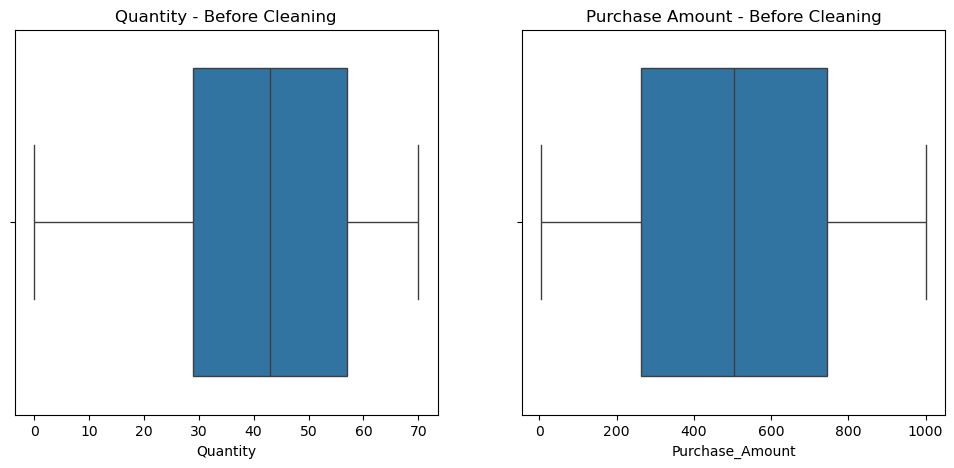

In [ ]:
#Boxplots help identify unusual values (outliers) and understand data distribution before cleaning#

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Quantity'])
plt.title('Quantity - Before Cleaning')

plt.subplot(1,2,2)
sns.boxplot(x=df['Purchase_Amount'])
plt.title('Purchase Amount - Before Cleaning')

plt.show()

In [25]:
# Quantity
qty_outliers, q_low, q_high = detect_outliers('Quantity')
print("Quantity Outliers Count:", len(qty_outliers))

# Purchase Amount
amt_outliers, a_low, a_high = detect_outliers('Purchase_Amount')
print("Purchase Amount Outliers Count:", len(amt_outliers))

Quantity Outliers Count: 0
Purchase Amount Outliers Count: 0


In [ ]:
#Shows unusual quantity values (too high or too low)#

print(qty_outliers)

#Shows unusual transaction amounts#

print(amt_outliers)

Empty DataFrame
Columns: [Customer_ID, Customer_Name, Quantity, Country, Product_Category, Purchase_Amount, Payment_Method, Transaction_Date]
Index: []
Empty DataFrame
Columns: [Customer_ID, Customer_Name, Quantity, Country, Product_Category, Purchase_Amount, Payment_Method, Transaction_Date]
Index: []


In [ ]:
#Total revenue shows the complete earnings of the business#

print("Total Revenue:", df['Purchase_Amount'].sum())

Total Revenue: 24442835.89


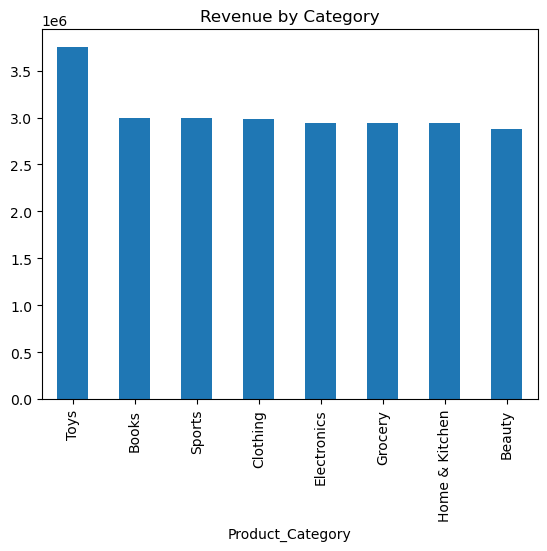

In [ ]:
#This graph shows which product categories earn the most and least revenue#

df.groupby('Product_Category')['Purchase_Amount'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Revenue by Category')
plt.show()

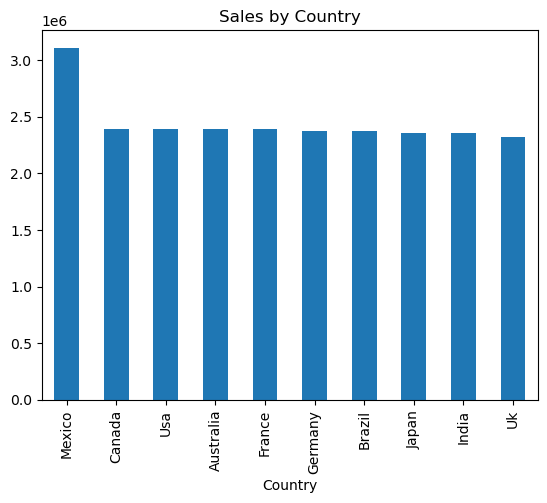

In [ ]:
#This chart shows which countries generate the most and least sales#

df.groupby('Country')['Purchase_Amount'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Sales by Country')
plt.show()

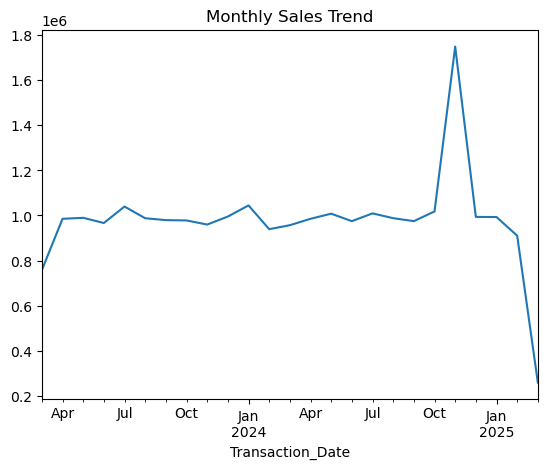

In [ ]:
#This graph shows how sales change every month (increase or decrease)#

df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

monthly = df.groupby(df['Transaction_Date'].dt.to_period('M'))['Purchase_Amount'].sum()

monthly.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.show()

In [ ]:
#Top 10 customers who spend the most money in the business#

Top_Customers = df.groupby('Customer_ID')['Purchase_Amount'].sum().sort_values(ascending=False).head(10)
print(Top_Customers)

Customer_ID
47133    999.98
41015    999.98
36985    999.95
19236    999.94
20014    999.93
39680    999.89
24800    999.89
28851    999.89
8135     999.87
13436    999.87
Name: Purchase_Amount, dtype: float64


In [ ]:
#Top Category = Most sold type of product#

print("Top Category:", df.groupby('Product_Category')['Purchase_Amount'].sum().idxmax())

#Top Country = Country giving most revenue#

print("Top Country:", df.groupby('Country')['Purchase_Amount'].sum().idxmax())

#Best Customer = Customer who spends the most#

print("Best Customer:", df.groupby('Customer_ID')['Purchase_Amount'].sum().idxmax())

Top Category: Toys
Top Country: Mexico
Best Customer: 41015


In [40]:
df.to_csv('cleaned_data.csv', index=False)